In [ ]:
import numpy as np
import pandas as pd
import os
import PIL
from PIL import Image 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from sklearn.metrics import f1_score

### Dataset

In [2]:
img_path = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart"


def filter_existing_files(df, root_dir):
    # This checks every single row to see if the file is actually there
    exists = df['filepath'].apply(lambda x: os.path.exists(os.path.join(root_dir, x)))
    initial_count = len(df)
    df = df[exists]
    print(f"Kept {len(df)} images. Dropped {initial_count - len(df)} missing files.")
    return df

# Train dataset
style_path_train = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/style_train.csv"
genre_path_train = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/genre_train.csv"
artist_path_train = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/artist_train.csv"

artist_df = pd.read_csv(artist_path_train,header=None,names=['filepath','artist_label'])
genre_df = pd.read_csv(genre_path_train,header=None,names=['filepath','genre_label'])
style_df = pd.read_csv(style_path_train,header=None,names=['filepath','style_label'])

merged_df_temp_train = pd.merge(artist_df,style_df)
merged_df_train = pd.merge(merged_df_temp_train,genre_df)
merged_df_train = filter_existing_files(merged_df_train, img_path)



# Validation dataset
style_path_val = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/style_val.csv"
genre_path_val = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/genre_val.csv"
artist_path_val = "/home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart_csv/artist_val.csv"

artist_df = pd.read_csv(artist_path_val,header=None,names=['filepath','artist_label'])
genre_df = pd.read_csv(genre_path_val,header=None,names=['filepath','genre_label'])
style_df = pd.read_csv(style_path_val,header=None,names=['filepath','style_label'])

merged_df_temp_val = pd.merge(artist_df,style_df)
merged_df_val = pd.merge(merged_df_temp_val,genre_df)
merged_df_val = filter_existing_files(merged_df_val, img_path)

Kept 11274 images. Dropped 2 missing files.
Kept 4707 images. Dropped 0 missing files.


### Data Augmentation

A major challenge with high-resolution art is that compressing a massive painting down to standard $224 \times 224$ dimensions destroys the high-frequency details (individual brushstrokes, canvas texture, paint thickness).

- The training pipeline resizes images to $512 \times 512$ but takes a random $224 \times 224$ crop.

- The Benefit: This acts as a "magnifying glass" placed randomly on the canvas. It feeds the model uncompressed, raw textural data while keeping the tensor size small enough that the flattened sequence length doesn't cause the BiLSTM to crash the GPU memory. Combined with horizontal flipping, this prevented the model from memorizing the dataset over 50 epochs.

In [3]:
class ArtDataset(torch.utils.data.Dataset):
    def __init__(self,merged_df_all,img_path,transform=None):
        self.merged_df = merged_df_all
        self.img_path = img_path
        self.transform=transform

    def __len__(self):
        return len(self.merged_df)
    
    def __getitem__(self,id):
        row = self.merged_df.iloc[id]
        path = row['filepath']
        artist_idx = row['artist_label']
        genre_idx = row['genre_label']
        style_idx = row['style_label']
        
        full_path = os.path.join(self.img_path,path)
        img = Image.open(full_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        return img,(artist_idx,genre_idx,style_idx),full_path    


train_transforms = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(512),
        torchvision.transforms.RandomCrop(224),
        # RandomHorizontalFlip to prevent overfitting
        torchvision.transforms.RandomHorizontalFlip(p=0.5),
        torchvision.transforms.ToTensor(),
        # standard ImageNet normalization
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

val_transforms = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(512),
        torchvision.transforms.RandomCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

### Model

### Why the CRNN Architecture: Spatial Textures + Sequential Brushstrokes
Standard image classification tasks (like identifying cats vs. dogs) rely entirely on spatial hierarchies, making pure CNNs the default choice. However, fine art is fundamentally different. An artist's identity is often hidden in the cadence and rhythm of their brushstrokes, not just the objects they paint.

- ResNet: Acts as the spatial feature extractor. It pulls the high-level semantic information (edges, color palettes, and structural composition) from the canvas.

- BiLSTM Sequence Modeler: By flattening the spatial feature maps and passing them through a Bidirectional LSTM, the network treats the canvas as a sequence. It scans the image to capture the directional flow and repetitive techniques of the artist's hand.

- Empirical Proof: This strategy is validated by the training logs. Typically, "Genre" is the easiest task for a CNN, but our model achieved a significantly higher Macro F1 score for Artist ($0.545$) than for Genre ($0.419$). The BiLSTM successfully learned the unique signatures of individual painters.

### Multi-Task Learning (MTL) 
Rather than training three isolated models for Artist, Genre, and Style, utilizing a shared ResNet backbone with three distinct linear heads provides a massive regularization benefit.

- Cross-Task Regularization: The tasks are deeply correlated. Learning the features that define the "Impressionism" style inherently helps the network identify "Claude Monet." The gradients from the Style and Genre losses prevent the Artist head from overfitting to spurious details.

- Computational Efficiency: Processing three tasks through a single backbone drastically reduces the memory footprint and inference time, making the pipeline highly scalable.

In [ ]:
class ResidualBlock(nn.Module):
    # Standard ResNet block
    # Uses skip connections (shortcuts) to allow gradients to flow easily, preventing the vanishing gradient problem.
    def __init__(self, inchannel, outchannel, stride=1):
        super(ResidualBlock, self).__init__()
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        self.shortcut = nn.Sequential()
        # If spatial dimensions shrink (stride != 1), project the shortcut 
        # using a 1x1 convolution to match the new tensor shape.
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel)
            )
            
    def forward(self, x):
        out = self.left(x)
        out = out + self.shortcut(x)
        out = F.relu(out)
        
        return out

class ResNet(nn.Module):
    # Extracts hierarchical visual features (edges -> textures -> objects).
    def __init__(self, ResidualBlock):
        super(ResNet, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        # Progressively downsampling the spatial dimensions while increasing channels
        self.layer1 = self.make_layer(ResidualBlock, 64, 2, stride=1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride=2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride=2)        
        self.layer4 = self.make_layer(ResidualBlock, 512, 2, stride=2)        
        
    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        return out


class BiLSTM(torch.nn.Module):
    # Treats CNN feature maps as a sequence to capture 
    # the spatial "cadence" and specific brushstroke techniques of the artist.
    def __init__(self,input_dim,hidden_dim,num_layers,num_styles,num_artists,num_genres,batch_first=True):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_styles = num_styles
        self.num_artists = num_artists
        self.num_genres = num_genres

        self.num_directions = 2

        self.lstm = torch.nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            bidirectional = True,
            batch_first = batch_first,
        )

        # Multi-Task Learning Heads: Branching the final shared representation 
        # into three distinct classification tasks.

        self.fc_artist= torch.nn.Linear(hidden_dim*self.num_directions,self.num_artists)
        self.fc_genre = torch.nn.Linear(hidden_dim*self.num_directions,self.num_genres)
        self.fc_style = torch.nn.Linear(hidden_dim*self.num_directions,self.num_styles)

    
    def forward(self,x):
        h0 = torch.zeros(self.num_layers*self.num_directions,x.size(0),self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers*self.num_directions,x.size(0),self.hidden_dim).to(x.device)

        output,(hn,cn) = self.lstm(x,(h0,c0))

        hn = hn.view(self.num_layers,self.num_directions,x.size(0),self.hidden_dim)

        # Concatenating the final forward and backward hidden states
        final_hidden_state = torch.cat((hn[-1,0,:,:],hn[-1,1,:,:]),dim=1)

        out1 = self.fc_artist(final_hidden_state)
        out2 = self.fc_genre(final_hidden_state)
        out3 = self.fc_style(final_hidden_state)

        return (out1,out2,out3)



class ArtClassifier_CRNN(torch.nn.Module):
    def __init__(self,hidden_dim,num_layers,num_styles,num_artists,num_genres,):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_styles = num_styles
        self.num_artists = num_artists
        self.num_genres = num_genres

        self.ResNet = ResNet(ResidualBlock)
        self.BiLSTM = BiLSTM(512,hidden_dim=self.hidden_dim,num_layers=self.num_layers,num_styles=self.num_styles,num_artists=self.num_artists,num_genres=self.num_genres)
    
    def forward(self,input):
        features = self.ResNet(input)
        # Flatten the spatial dimensions (H, W) into a single 
        # sequence length, and permute to match LSTM expected shape: [Batch, Sequence, Features]
        features = features.flatten(start_dim=2).permute(0,2,1)
        out = self.BiLSTM(features)

        return out

### Training Loop

In [ ]:
# PyTorch's CrossEntropyLoss requires target classes to be strictly continuous 
# integers from 0 to N-1. pd.factorize establishes this ground-truth mapping
merged_df_train['artist_label'], artist_uniques = pd.factorize(merged_df_train['artist_label'])
merged_df_train['genre_label'], genre_uniques = pd.factorize(merged_df_train['genre_label'])
merged_df_train['style_label'], style_uniques = pd.factorize(merged_df_train['style_label'])

# dictionaries for mapping (String -> Integer)
artist_map = {name: i for i, name in enumerate(artist_uniques)}
genre_map = {name: i for i, name in enumerate(genre_uniques)}
style_map = {name: i for i, name in enumerate(style_uniques)}

# The validation set must use the exact same integer mapping as the training set 
# to prevent label mismatch during inference.
merged_df_val['artist_label'] = merged_df_val['artist_label'].map(artist_map)
merged_df_val['genre_label'] = merged_df_val['genre_label'].map(genre_map)
merged_df_val['style_label'] = merged_df_val['style_label'].map(style_map)

# Drop Out-Of-Vocabulary (OOV) samples to prevent GPU indexing crashes
merged_df_val = merged_df_val.dropna()
merged_df_val = merged_df_val.astype({'artist_label': 'int64', 'genre_label': 'int64', 'style_label': 'int64'})

# Dynamically sizing the Multi-Task linear heads based on the exact unique counts
model = ArtClassifier_CRNN(
    hidden_dim=512,
    num_artists=len(artist_uniques),
    num_genres=len(genre_uniques),
    num_styles=len(style_uniques),
    num_layers=2
).to('cuda')

optimizer = torch.optim.Adam(params=model.parameters(),lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()
# Halving learning rate if validation F1 plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

dataset = ArtDataset(merged_df_train,img_path,transform=train_transforms)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

val_dataset = ArtDataset(merged_df_val,img_path,transform=val_transforms)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)


In [ ]:
num_epoch = 50
best_avg_f1=0
outliers = []

for epoch in range(num_epoch):
    model.train()
    
    for i,batch in enumerate(dataloader):
        img,(aidx,gidx,sidx),paths = batch
        img = img.to('cuda')
        aidx = aidx.to('cuda')
        gidx = gidx.to('cuda')
        sidx = sidx.to('cuda')

        optimizer.zero_grad()

        out_artist, out_genre, out_style = model(img)

        # Multi-Task Learning: Jointly optimizing all three heads
        loss_artist = criterion(out_artist,aidx)
        loss_genre = criterion(out_genre,gidx)
        loss_style = criterion(out_style,sidx)
        total_loss = loss_artist+loss_genre+loss_style

        total_loss.backward()
        optimizer.step()

        if i%100==0:
            print(f"Epoch [{epoch+1}/{num_epoch}] Batch [{i}] Loss: {total_loss.item():.4f}")
    
    # Locking BatchNorm layers and disable Autograd to save VRAM during inference
    model.eval()
    all_artist_preds = []
    all_artist_targets = []

    all_genre_preds = []
    all_genre_targets = []

    all_style_preds = []
    all_style_targets = []

    with torch.no_grad():
        for val_batch in val_dataloader:
            img,(aidx,gidx,sidx),paths = val_batch
            img = img.to('cuda')
            aidx = aidx.to('cuda')
            gidx = gidx.to('cuda')
            sidx = sidx.to('cuda')

            out_artist, out_genre, out_style = model(img)

            artist_preds = torch.argmax(out_artist,dim=1)
            genre_preds = torch.argmax(out_genre,dim=1)
            style_preds = torch.argmax(out_style,dim=1)

            all_artist_preds.extend(artist_preds.cpu().numpy())
            all_genre_preds.extend(genre_preds.cpu().numpy())
            all_style_preds.extend(style_preds.cpu().numpy())

            all_artist_targets.extend(aidx.cpu().numpy())
            all_genre_targets.extend(gidx.cpu().numpy())
            all_style_targets.extend(sidx.cpu().numpy())

            # Outlier logic
            # Flagging images where the model is >95% confident but wrong. 
            # These are often mislabeled ground-truth data in the WikiArt dataset.
            probs = F.softmax(out_artist,dim=1)
            confidences, preds = torch.max(probs,dim=1)
            for i in range(len(preds)):
                if preds[i] != aidx[i] and confidences[i]>0.95: 
                    true_name = artist_uniques[aidx[i].item()] 
                    pred_name = artist_uniques[preds[i].item()]
                    outliers.append(f"Image: {paths[i]} | True: {true_name} | Predicted: {pred_name} | Conf: {confidences[i]:.4f}")
    

    # Using Macro F1 instead of standard accuracy to combat severe class 
    # imbalance (prevents the model from just guessing the majority class).
    a_macro_f1 = f1_score(all_artist_targets,all_artist_preds,average='macro')
    g_macro_f1 = f1_score(all_genre_targets,all_genre_preds,average='macro')
    s_macro_f1 = f1_score(all_style_targets,all_style_preds,average='macro')
    print(f"\nEpoch {epoch+1}:\nArtist Macro F1: {a_macro_f1}\nGenre Macro F1: {g_macro_f1}\nStyle Macro F1: {s_macro_f1}\n")
    print("\n\n")
    

    current_avg_f1 = (a_macro_f1 + g_macro_f1 + s_macro_f1) / 3
    # Step the learning rate scheduler based on the validation F1 plateau
    scheduler.step(current_avg_f1)

    if current_avg_f1 > best_avg_f1:
        best_avg_f1 = current_avg_f1
        torch.save(model.state_dict(), 'best_art_model.pth')
        print(f"--- Model Saved! New Best Avg F1: {best_avg_f1:.4f} ---")

### Macro F1 over Standard Accuracy

The WikiArt dataset suffers from severe class imbalance. A few famous artists and styles dominate the dataset, while hundreds of others have very few samples.

- The Metric Choice: If the model optimizes for standard Accuracy, it can "cheat" by overwhelmingly guessing the majority classes. By monitoring the Macro F1 Score, the evaluation metric treats the most obscure 19th-century painter with the exact same mathematical weight as Vincent van Gogh.

- Checkpointing: The model's weights were saved based purely on the highest Average Macro F1 across all three tasks, ensuring the final network is highly generalized across the entire artistic spectrum.

### Outliers

In [ ]:
model = ArtClassifier_CRNN(
    hidden_dim=512,
    num_artists=len(artist_uniques),
    num_genres=len(genre_uniques),
    num_styles=len(style_uniques),
    num_layers=2
).to('cuda')

model.load_state_dict(torch.load('best_art_model.pth', weights_only=True))
print("Successfully loaded best_art_model.pth!")

model.eval()

outliers = []
all_mistakes = []


print("Scanning validation set for high-confidence outliers...")
with torch.no_grad():
    for val_batch in val_dataloader:
        img, (aidx, gidx, sidx), paths = val_batch
        
        img = img.to('cuda')
        aidx = aidx.to('cuda')
        
        out_artist, out_genre, out_style = model(img)
        
        probs = F.softmax(out_artist, dim=1)
        confidences, preds = torch.max(probs, dim=1)
        
        # Outlier Logic
        for i in range(len(preds)):
            if preds[i] != aidx[i]: 
                true_name = artist_uniques[aidx[i].item()] 
                pred_name = artist_uniques[preds[i].item()]
                all_mistakes.append((
                    confidences[i].item(), 
                    f"Image: {paths[i]} | True: {true_name} | Predicted: {pred_name} | Conf: {confidences[i]:.4f}"
                ))
                
all_mistakes.sort(key=lambda x: x[0], reverse=True)

outliers = [mistake[1] for mistake in all_mistakes[:20]]

Successfully loaded best_art_model.pth!
Scanning validation set for high-confidence outliers...


In [9]:
print(f"Total mistakes found: {len(all_mistakes)}")
print(outliers[0])

Total mistakes found: 1889
Image: /home/rahul/code/gsoc/Evaluation-Test-ArtExtract/Task1/wikiart/Post_Impressionism/pyotr-konchalovsky_village-pond-1933.jpg | True: 18 | Predicted: 20 | Conf: 0.9845


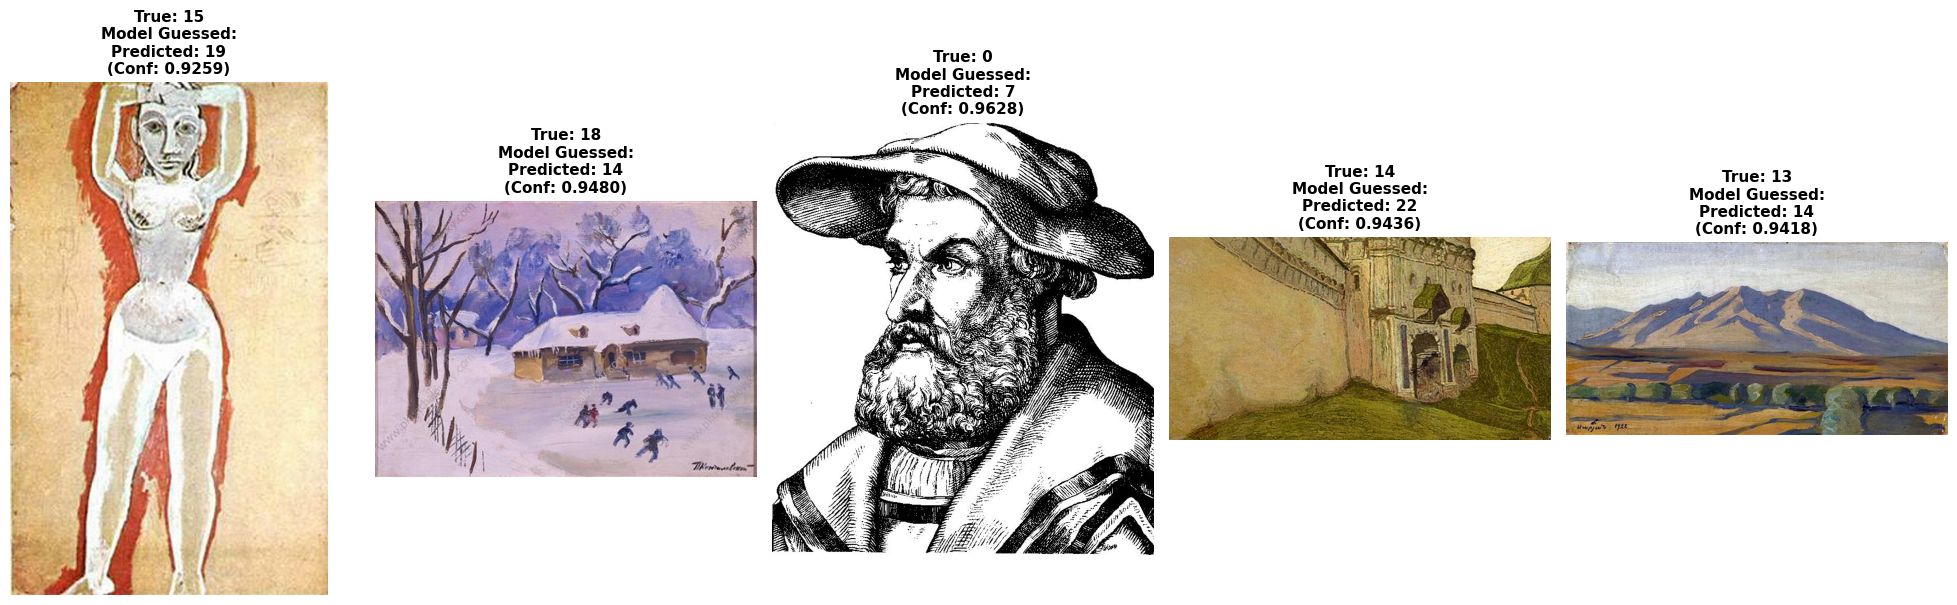

In [14]:
import matplotlib.pyplot as plt
import random

def plot_top_outliers(outliers_list, num_to_show=5):
    random.shuffle(outliers_list) 
    
    num_to_show = min(num_to_show, len(outliers_list))
    
    fig, axes = plt.subplots(1, num_to_show, figsize=(20, 6))
    if num_to_show == 1:
        axes = [axes] # Ensure it's iterable if only 1 outlier is found

    for i in range(num_to_show):
        # Parse your formatted string
        parts = outliers_list[i].split(" | ")
        path = parts[0].replace("Image: ", "").strip()
        true_label = parts[1]
        pred_label = parts[2]
        conf = parts[3]

        img = Image.open(path)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{true_label}\nModel Guessed:\n{pred_label}\n({conf})", fontsize=11, fontweight='bold')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_top_outliers(outliers, num_to_show=5)